In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
dataFrame = [
    "C:/Users/Hype/Documents/Perkuliahan/Semester 4/Data Mining/UAS/Ikan/Permintaan_anggafadzar21_upi_edu_1748165460.csv",
    "C:/Users/Hype/Documents/Perkuliahan/Semester 4/Data Mining/UAS/Ikan/Permintaan_anggafadzar21_upi_edu_1748165625.csv",
    "C:/Users/Hype/Documents/Perkuliahan/Semester 4/Data Mining/UAS/Ikan/Permintaan_anggafadzar21_upi_edu_1748165711.csv",
    "C:/Users/Hype/Documents/Perkuliahan/Semester 4/Data Mining/UAS/Ikan/Permintaan_anggafadzar21_upi_edu_1748165826.csv",
    "C:/Users/Hype/Documents/Perkuliahan/Semester 4/Data Mining/UAS/Ikan/Permintaan_anggafadzar21_upi_edu_1748165955.csv"
]

df = pd.concat([pd.read_csv(path, on_bad_lines='skip') for path in dataFrame], ignore_index=True)

df.head(10)

,Tahun,Provinsi,Kabupaten/Kota,Kelompok,Jenis Ikan,Jenis Usaha,Volume (ton),Nilai (Rp. Juta),Harga Rata-Rata Tertimbang (Rp/kg);
0,2019,BANTEN,KOTA CILEGON,ALU-ALU,ALU-ALU SIRIP HITAM;,NaN,NaN,NaN,NaN
1,2019,BANTEN,KOTA CILEGON,BELANAK,BELANAK,LAUT,440.20,8804.0,20000;
2,2019,BANTEN,KOTA CILEGON,BELOSO,BELOSO,LAUT,420.78,7952.0,18898;
3,2019,BANTEN,KOTA CILEGON,CUMI-CUMI,CUMI-CUMI,LAUT,314.50,12596.0,40052;
4,2019,BANTEN,KOTA CILEGON,GEROT-GEROT,GEROT-GEROT,LAUT,1.23,34.0,28000;
5,2019,BANTEN,KOTA CILEGON,HIU,HIU BOTOL,LAUT,46.07,552.0,11980;
6,2019,BANTEN,KOTA CILEGON,IKAN LAINNYA,IKAN LAINNYA,LAUT,18.40,221.0,12000;
7,2019,BANTEN,KOTA CILEGON,KAKAP,JENAHA,LAUT,47.96,2028.0,42280;
8,2019,BANTEN,KOTA CILEGON,KAKAP,KAKAP MERAH,LAUT,270.20,13110.0,48519;
9,2019,BANTEN,KOTA CILEGON,KAKAP,TAMBANGAN,LAUT,32.24,580.0,18000;


In [3]:
for col in ['Volume (ton)', 'Nilai (Rp. Juta)', 'Harga Rata-Rata Tertimbang (Rp/kg);']:
    df[col] = df[col].astype(str).str.replace(';', '').str.replace(',', '.')
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [4]:
df.dtypes

Tahun                                   object
Provinsi                                object
Kabupaten/Kota                          object
Kelompok                                object
Jenis Ikan                              object
Jenis Usaha                             object
Volume (ton)                           float64
Nilai (Rp. Juta)                       float64
Harga Rata-Rata Tertimbang (Rp/kg);    float64
dtype: object

In [5]:
df.dropna(subset=['Volume (ton)', 'Nilai (Rp. Juta)', 'Harga Rata-Rata Tertimbang (Rp/kg);'], inplace=True)
df.head(10)

,Tahun,Provinsi,Kabupaten/Kota,Kelompok,Jenis Ikan,Jenis Usaha,Volume (ton),Nilai (Rp. Juta),Harga Rata-Rata Tertimbang (Rp/kg);
1,2019,BANTEN,KOTA CILEGON,BELANAK,BELANAK,LAUT,440.20,8804.0,20000.0
2,2019,BANTEN,KOTA CILEGON,BELOSO,BELOSO,LAUT,420.78,7952.0,18898.0
3,2019,BANTEN,KOTA CILEGON,CUMI-CUMI,CUMI-CUMI,LAUT,314.50,12596.0,40052.0
4,2019,BANTEN,KOTA CILEGON,GEROT-GEROT,GEROT-GEROT,LAUT,1.23,34.0,28000.0
5,2019,BANTEN,KOTA CILEGON,HIU,HIU BOTOL,LAUT,46.07,552.0,11980.0
6,2019,BANTEN,KOTA CILEGON,IKAN LAINNYA,IKAN LAINNYA,LAUT,18.40,221.0,12000.0
7,2019,BANTEN,KOTA CILEGON,KAKAP,JENAHA,LAUT,47.96,2028.0,42280.0
8,2019,BANTEN,KOTA CILEGON,KAKAP,KAKAP MERAH,LAUT,270.20,13110.0,48519.0
9,2019,BANTEN,KOTA CILEGON,KAKAP,TAMBANGAN,LAUT,32.24,580.0,18000.0
10,2019,BANTEN,KOTA CILEGON,KEMBUNG,KEMBUNG,LAUT,249.20,1994.0,8000.0


In [6]:
for i, kota in enumerate(df['Kabupaten/Kota'].unique(), 1):
    print(f"{i}. {kota}")

1. KOTA CILEGON
2. KOTA SERANG
3. LEBAK
4. PANDEGLANG
5. SERANG
6. TANGERANG


In [7]:
# Label encoding otomatis berdasarkan isi kolom
df['Kabupaten Kota'] = df['Kabupaten/Kota'].astype('category').cat.codes

# Cek hasilnya
df[['Kabupaten/Kota', 'Kabupaten Kota']].drop_duplicates().sort_values('Kabupaten Kota').head()

,Kabupaten/Kota,Kabupaten Kota
1,KOTA CILEGON,0
29,KOTA SERANG,1
109,LEBAK,2
162,PANDEGLANG,3
269,SERANG,4


In [8]:
df.dtypes

Tahun                                   object
Provinsi                                object
Kabupaten/Kota                          object
Kelompok                                object
Jenis Ikan                              object
Jenis Usaha                             object
Volume (ton)                           float64
Nilai (Rp. Juta)                       float64
Harga Rata-Rata Tertimbang (Rp/kg);    float64
Kabupaten Kota                            int8
dtype: object

In [9]:
# Label encoding otomatis berdasarkan isi kolom
df['Jenis Ikan (kode)'] = df['Jenis Ikan'].astype('category').cat.codes

# Cek hasilnya
df[['Jenis Ikan', 'Jenis Ikan (kode)']].drop_duplicates().sort_values('Jenis Ikan (kode)').head()

,Jenis Ikan,Jenis Ikan (kode)
1634,ABAT,0
26,ALBAKORA,1
269,ALU-ALU BESAR; UDANG API-API,2
1105,ALU-ALU MATA BESAR; BARAKUDA BESAR,3
747,ALU-ALU OBTUSE; BARAKUDA BESAR,4


In [10]:
df.dtypes

Tahun                                   object
Provinsi                                object
Kabupaten/Kota                          object
Kelompok                                object
Jenis Ikan                              object
Jenis Usaha                             object
Volume (ton)                           float64
Nilai (Rp. Juta)                       float64
Harga Rata-Rata Tertimbang (Rp/kg);    float64
Kabupaten Kota                            int8
Jenis Ikan (kode)                        int16
dtype: object

In [11]:
df.head()

,Tahun,Provinsi,Kabupaten/Kota,Kelompok,Jenis Ikan,Jenis Usaha,Volume (ton),Nilai (Rp. Juta),Harga Rata-Rata Tertimbang (Rp/kg);,Kabupaten Kota,Jenis Ikan (kode)
1,2019,BANTEN,KOTA CILEGON,BELANAK,BELANAK,LAUT,440.20,8804.0,20000.0,0,17
2,2019,BANTEN,KOTA CILEGON,BELOSO,BELOSO,LAUT,420.78,7952.0,18898.0,0,20
3,2019,BANTEN,KOTA CILEGON,CUMI-CUMI,CUMI-CUMI,LAUT,314.50,12596.0,40052.0,0,27
4,2019,BANTEN,KOTA CILEGON,GEROT-GEROT,GEROT-GEROT,LAUT,1.23,34.0,28000.0,0,32
5,2019,BANTEN,KOTA CILEGON,HIU,HIU BOTOL,LAUT,46.07,552.0,11980.0,0,38


In [12]:
for k, jenis in enumerate(df['Tahun'].unique(), 1):
    print(f"{k}. {jenis}")

1. 2019
2. 2020
3. 2021
4. 2022
5. 2023


In [13]:
for col in ['Tahun']:
    df[col] = df[col].astype(str).str.replace(';', '').str.replace(',', '.')
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [14]:
df.head(10)

,Tahun,Provinsi,Kabupaten/Kota,Kelompok,Jenis Ikan,Jenis Usaha,Volume (ton),Nilai (Rp. Juta),Harga Rata-Rata Tertimbang (Rp/kg);,Kabupaten Kota,Jenis Ikan (kode)
1,2019,BANTEN,KOTA CILEGON,BELANAK,BELANAK,LAUT,440.20,8804.0,20000.0,0,17
2,2019,BANTEN,KOTA CILEGON,BELOSO,BELOSO,LAUT,420.78,7952.0,18898.0,0,20
3,2019,BANTEN,KOTA CILEGON,CUMI-CUMI,CUMI-CUMI,LAUT,314.50,12596.0,40052.0,0,27
4,2019,BANTEN,KOTA CILEGON,GEROT-GEROT,GEROT-GEROT,LAUT,1.23,34.0,28000.0,0,32
5,2019,BANTEN,KOTA CILEGON,HIU,HIU BOTOL,LAUT,46.07,552.0,11980.0,0,38
6,2019,BANTEN,KOTA CILEGON,IKAN LAINNYA,IKAN LAINNYA,LAUT,18.40,221.0,12000.0,0,45
7,2019,BANTEN,KOTA CILEGON,KAKAP,JENAHA,LAUT,47.96,2028.0,42280.0,0,47
8,2019,BANTEN,KOTA CILEGON,KAKAP,KAKAP MERAH,LAUT,270.20,13110.0,48519.0,0,57
9,2019,BANTEN,KOTA CILEGON,KAKAP,TAMBANGAN,LAUT,32.24,580.0,18000.0,0,174
10,2019,BANTEN,KOTA CILEGON,KEMBUNG,KEMBUNG,LAUT,249.20,1994.0,8000.0,0,64


In [15]:
df.dtypes

Tahun                                    int64
Provinsi                                object
Kabupaten/Kota                          object
Kelompok                                object
Jenis Ikan                              object
Jenis Usaha                             object
Volume (ton)                           float64
Nilai (Rp. Juta)                       float64
Harga Rata-Rata Tertimbang (Rp/kg);    float64
Kabupaten Kota                            int8
Jenis Ikan (kode)                        int16
dtype: object

In [16]:
X = df[['Tahun', 'Kabupaten Kota', 'Jenis Ikan (kode)', 'Volume (ton)', 'Nilai (Rp. Juta)']]
y = df['Harga Rata-Rata Tertimbang (Rp/kg);']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 4]
}

In [19]:
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [5, 10, 15],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 200]},
             scoring='r2')

In [20]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Best Parameters:", grid_search.best_params_)
print("R² Score:", r2)
print("RMSE:", rmse)

Best Parameters: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
R² Score: 0.9194486637205396
RMSE: 11925.541063878993


In [21]:
import joblib

# Simpan model terbaik ke file
joblib.dump(best_model, 'model_rf.pkl')

['model_rf.pkl']

In [22]:
df['Jenis Ikan'] = df['Jenis Ikan'].str.strip().str.upper()
df['Kabupaten/Kota'] = df['Kabupaten/Kota'].str.strip().str.upper()

# Baru buat mapping
ikan_reverse = {v: k for k, v in dict(enumerate(df['Jenis Ikan'].astype('category').cat.categories)).items()}
kabupaten_reverse = {v: k for k, v in dict(enumerate(df['Kabupaten/Kota'].astype('category').cat.categories)).items()}

joblib.dump({'ikan': ikan_reverse, 'kabupaten': kabupaten_reverse}, 'mappings.pkl')

['mappings.pkl']

In [23]:
df['Jenis Ikan'] = df['Jenis Ikan'].astype(str)
df['Jenis Ikan'] = df['Jenis Ikan'].str.upper().str.strip()

# Pisahkan gabungan nama ikan
ikan_unik = set()
for entry in df['Jenis Ikan']:
    for nama in entry.split(';'):
        ikan_unik.add(nama.strip())

ikan_mapping = {nama: idx for idx, nama in enumerate(sorted(ikan_unik))}

In [24]:
df.head()

,Tahun,Provinsi,Kabupaten/Kota,Kelompok,Jenis Ikan,Jenis Usaha,Volume (ton),Nilai (Rp. Juta),Harga Rata-Rata Tertimbang (Rp/kg);,Kabupaten Kota,Jenis Ikan (kode)
1,2019,BANTEN,KOTA CILEGON,BELANAK,BELANAK,LAUT,440.20,8804.0,20000.0,0,17
2,2019,BANTEN,KOTA CILEGON,BELOSO,BELOSO,LAUT,420.78,7952.0,18898.0,0,20
3,2019,BANTEN,KOTA CILEGON,CUMI-CUMI,CUMI-CUMI,LAUT,314.50,12596.0,40052.0,0,27
4,2019,BANTEN,KOTA CILEGON,GEROT-GEROT,GEROT-GEROT,LAUT,1.23,34.0,28000.0,0,32
5,2019,BANTEN,KOTA CILEGON,HIU,HIU BOTOL,LAUT,46.07,552.0,11980.0,0,38


In [25]:
# Misal sudah punya ikan_mapping dan kabupaten_mapping

mappings = {
    'ikan': ikan_mapping,
    'kabupaten': kabupaten_reverse
}

import joblib
joblib.dump(mappings, 'mappings.pkl')


['mappings.pkl']

In [26]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import matplotlib.pyplot as plt

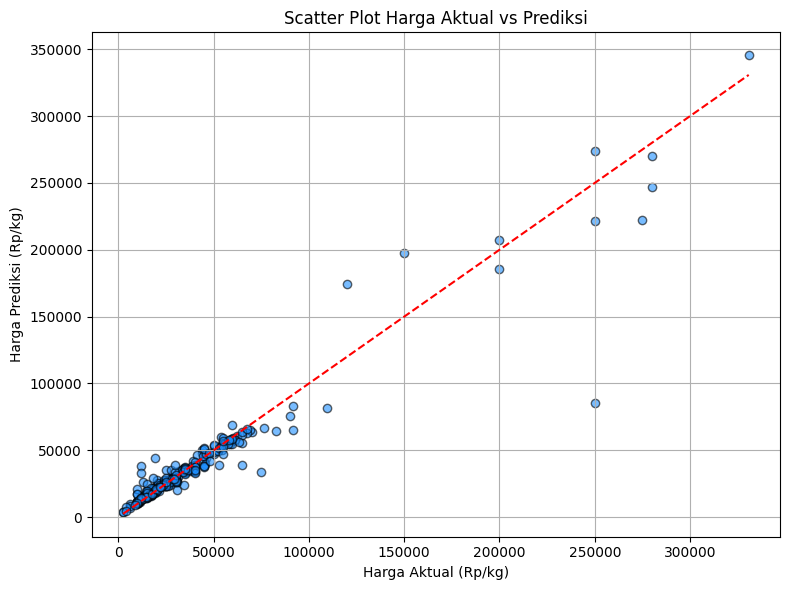

In [28]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='dodgerblue', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Garis y=x
plt.xlabel('Harga Aktual (Rp/kg)')
plt.ylabel('Harga Prediksi (Rp/kg)')
plt.title('Scatter Plot Harga Aktual vs Prediksi')
plt.grid(True)
plt.tight_layout()
plt.show()

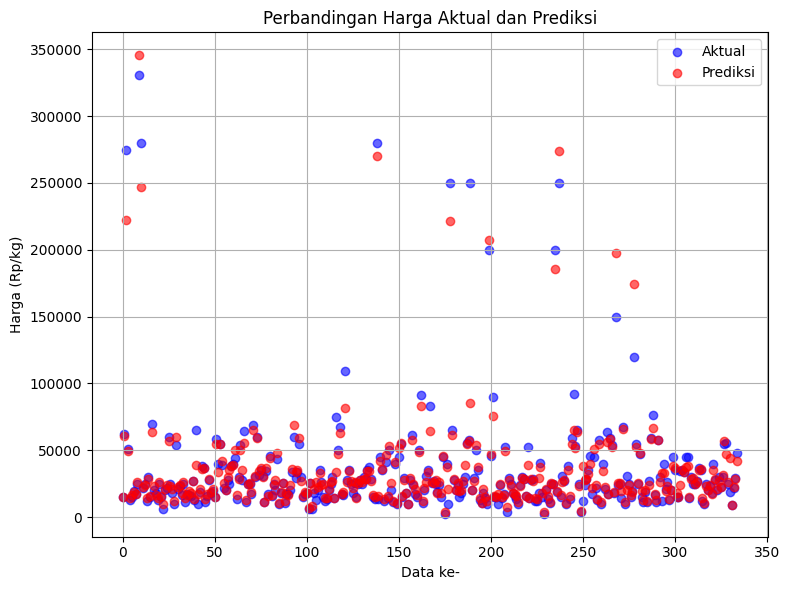

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(range(len(y_test)), y_test, color='blue', label='Aktual', alpha=0.6)
plt.scatter(range(len(y_pred)), y_pred, color='red', label='Prediksi', alpha=0.6)
plt.xlabel('Data ke-')
plt.ylabel('Harga (Rp/kg)')
plt.title('Perbandingan Harga Aktual dan Prediksi')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

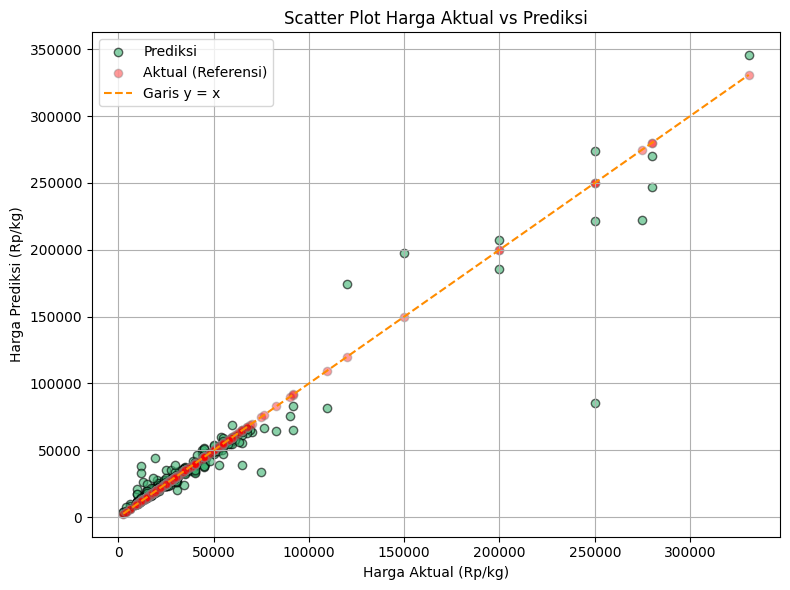

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Titik scatter: hubungan antara harga aktual (x) dan prediksi (y)
plt.scatter(y_test, y_pred, alpha=0.6, color='mediumseagreen', edgecolors='black', label='Prediksi')

# Titik diagonal aktual (untuk acuan)
plt.scatter(y_test, y_test, alpha=0.4, color='red', edgecolors='gray', label='Aktual (Referensi)')

# Garis y = x
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='darkorange', linestyle='--', label='Garis y = x')

plt.xlabel('Harga Aktual (Rp/kg)')
plt.ylabel('Harga Prediksi (Rp/kg)')
plt.title('Scatter Plot Harga Aktual vs Prediksi')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

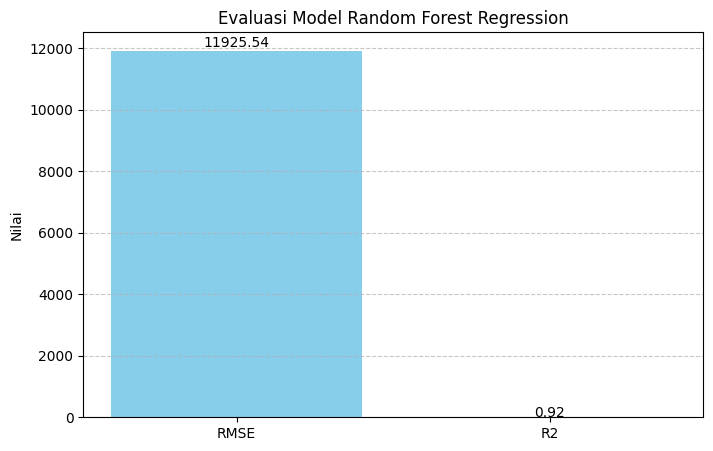

In [31]:
import matplotlib.pyplot as plt

metrics = ['RMSE', 'R2']
values = [rmse, r2]

plt.figure(figsize=(8,5))
bars = plt.bar(metrics, values, color=['skyblue', 'orange', 'green', 'purple'])
plt.title('Evaluasi Model Random Forest Regression')
plt.ylabel('Nilai')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Label nilai di atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height * 1.01, f'{height:.2f}', ha='center', fontsize=10)

plt.show()


In [32]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
import seaborn as sns

C:\Users\Hype\AppData\Local\Temp\ipykernel_10764\1103164519.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importances, y=sorted_features, palette='viridis')


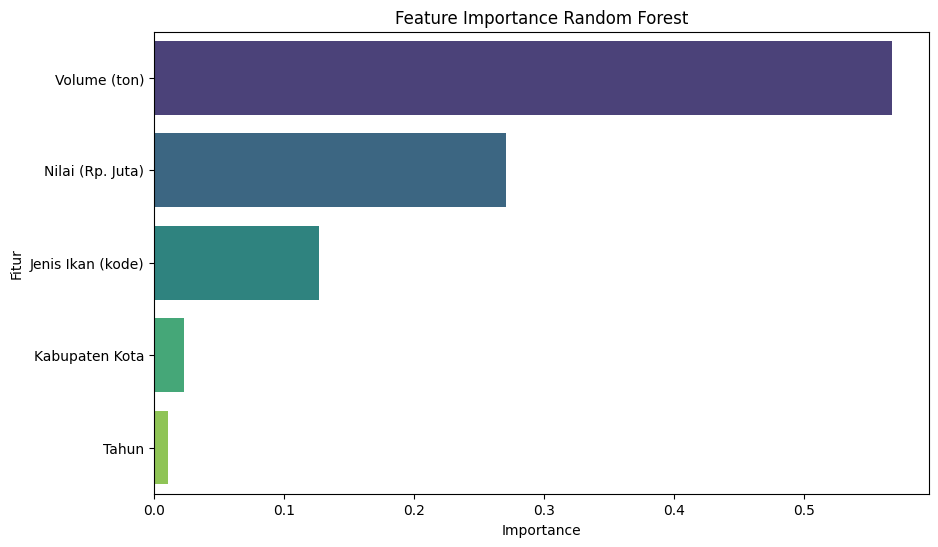

In [34]:
importances = best_model.feature_importances_
features = X.columns  # fitur yang kamu pakai

# Sorting fitur berdasarkan importance
indices = importances.argsort()[::-1]
sorted_features = features[indices]
sorted_importances = importances[indices]

plt.figure(figsize=(10,6))
sns.barplot(x=sorted_importances, y=sorted_features, palette='viridis')
plt.title('Feature Importance Random Forest')
plt.xlabel('Importance')
plt.ylabel('Fitur')
plt.show()


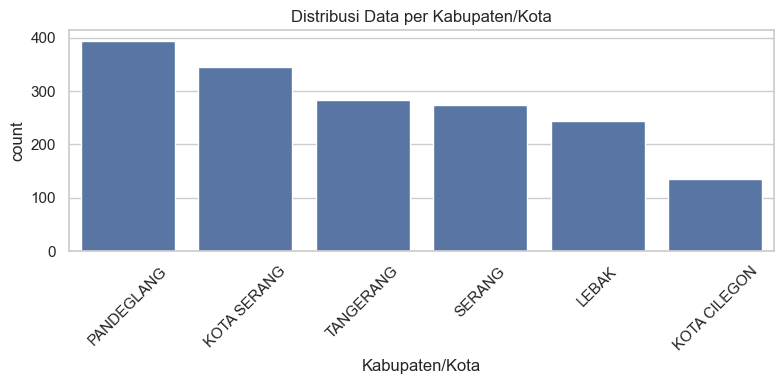

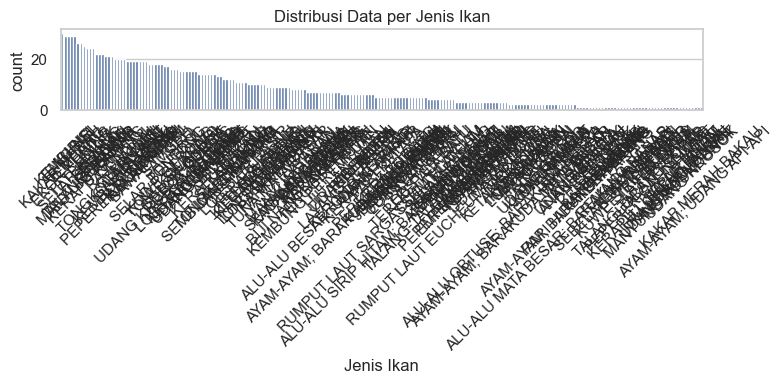

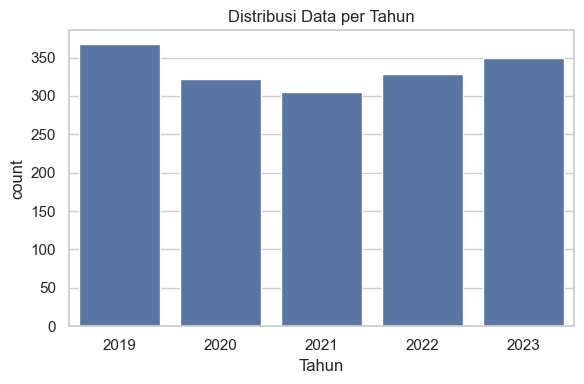

In [35]:
# Set style
sns.set(style="whitegrid")

# Plot distribusi per Kabupaten/Kota
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="Kabupaten/Kota", order=df["Kabupaten/Kota"].value_counts().index)
plt.title("Distribusi Data per Kabupaten/Kota")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot distribusi per Jenis Ikan
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="Jenis Ikan", order=df["Jenis Ikan"].value_counts().index)
plt.title("Distribusi Data per Jenis Ikan")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot distribusi per Tahun
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Tahun", order=sorted(df["Tahun"].unique()))
plt.title("Distribusi Data per Tahun")
plt.tight_layout()
plt.show()

In [36]:
pip install matplotlib-venn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\Hype\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib_venn\layout\venn2\exact.py:83: UserWarning: Both circles have zero area
  warnings.warn("Both circles have zero area")


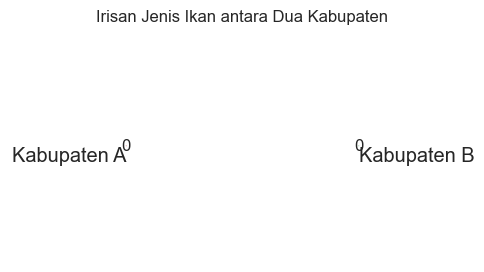

In [37]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

# Contoh: bandingkan jenis ikan di 2 kabupaten
kab1 = "Kabupaten A"
kab2 = "Kabupaten B"

ikan_kab1 = set(df[df["Kabupaten/Kota"] == kab1]["Jenis Ikan"].unique())
ikan_kab2 = set(df[df["Kabupaten/Kota"] == kab2]["Jenis Ikan"].unique())

plt.figure(figsize=(6, 6))
venn2([ikan_kab1, ikan_kab2], set_labels=(kab1, kab2))
plt.title("Irisan Jenis Ikan antara Dua Kabupaten")
plt.show()


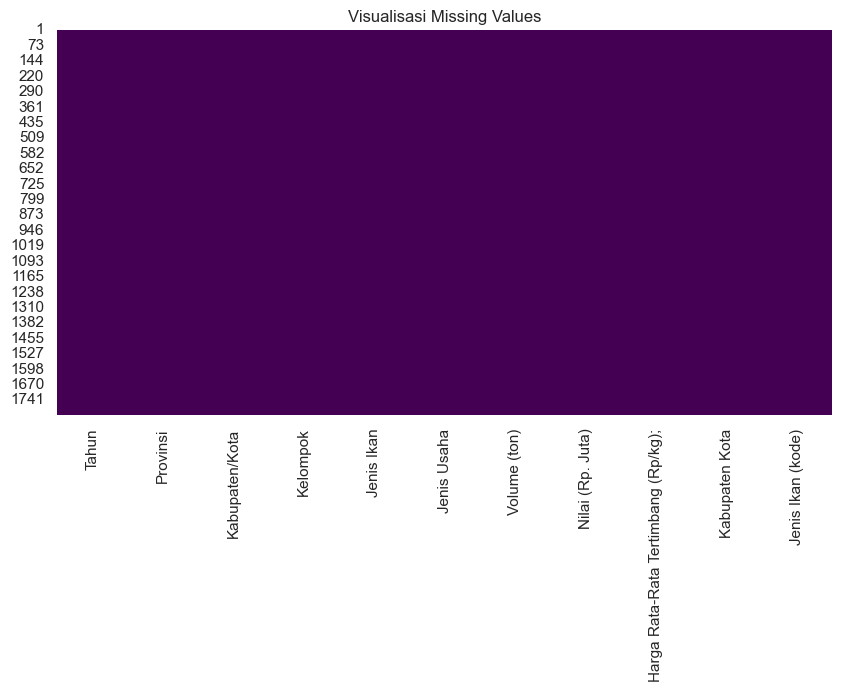

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Visualisasi Missing Values')
plt.show()


In [39]:
df.head()

,Tahun,Provinsi,Kabupaten/Kota,Kelompok,Jenis Ikan,Jenis Usaha,Volume (ton),Nilai (Rp. Juta),Harga Rata-Rata Tertimbang (Rp/kg);,Kabupaten Kota,Jenis Ikan (kode)
1,2019,BANTEN,KOTA CILEGON,BELANAK,BELANAK,LAUT,440.20,8804.0,20000.0,0,17
2,2019,BANTEN,KOTA CILEGON,BELOSO,BELOSO,LAUT,420.78,7952.0,18898.0,0,20
3,2019,BANTEN,KOTA CILEGON,CUMI-CUMI,CUMI-CUMI,LAUT,314.50,12596.0,40052.0,0,27
4,2019,BANTEN,KOTA CILEGON,GEROT-GEROT,GEROT-GEROT,LAUT,1.23,34.0,28000.0,0,32
5,2019,BANTEN,KOTA CILEGON,HIU,HIU BOTOL,LAUT,46.07,552.0,11980.0,0,38


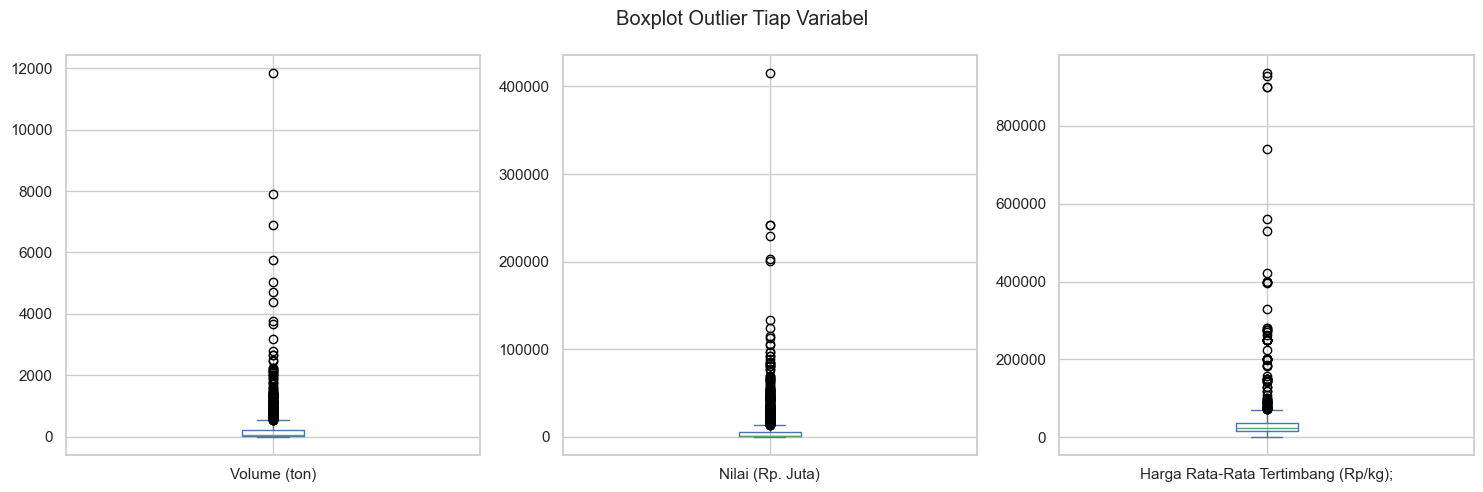

In [40]:
numeric_cols = ['Volume (ton)', 'Nilai (Rp. Juta)', 'Harga Rata-Rata Tertimbang (Rp/kg);']
df[numeric_cols].plot(kind='box', subplots=True, layout=(1, 3), figsize=(15, 5), title='Boxplot Outlier Tiap Variabel')
plt.tight_layout()
plt.show()


In [41]:
print("Sebelum Encoding:")
print(df[['Kabupaten/Kota', 'Jenis Ikan']].head())

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Kabupaten_encoded'] = le.fit_transform(df['Kabupaten/Kota'])
df['Ikan_encoded'] = le.fit_transform(df['Jenis Ikan'])

print("Sesudah Encoding:")
print(df[['Kabupaten_encoded', 'Ikan_encoded']].head())


Sebelum Encoding:
  Kabupaten/Kota   Jenis Ikan
1   KOTA CILEGON      BELANAK
2   KOTA CILEGON       BELOSO
3   KOTA CILEGON    CUMI-CUMI
4   KOTA CILEGON  GEROT-GEROT
5   KOTA CILEGON    HIU BOTOL
Sesudah Encoding:
   Kabupaten_encoded  Ikan_encoded
1                  0            17
2                  0            20
3                  0            27
4                  0            32
5                  0            38


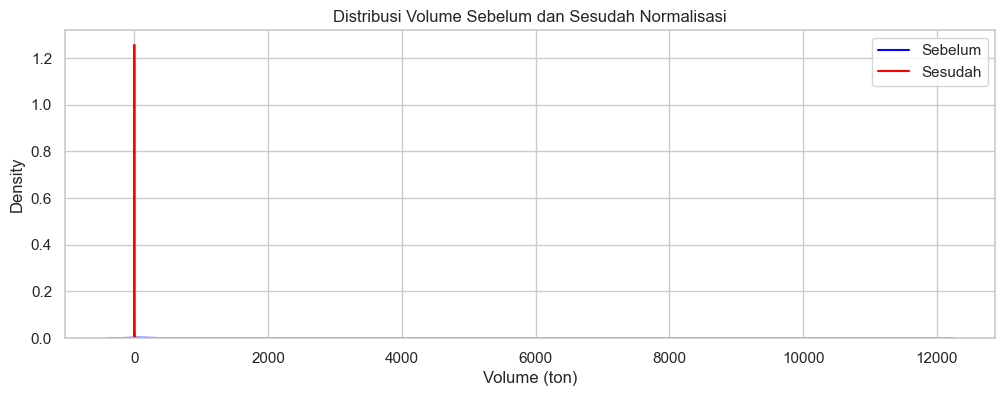

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[['Volume (ton)', 'Nilai (Rp. Juta)']])

# Plot distribusi
plt.figure(figsize=(12, 4))
sns.kdeplot(df['Volume (ton)'], label='Sebelum', color='blue')
sns.kdeplot(scaled_data[:, 0], label='Sesudah', color='red')
plt.title('Distribusi Volume Sebelum dan Sesudah Normalisasi')
plt.legend()
plt.show()
